
# Karate Club

Zachary's Karate Club graph

Data file from:
http://vlado.fmf.uni-lj.si/pub/networks/data/Ucinet/UciData.htm

Zachary W. (1977).
An information flow model for conflict and fission in small groups.
Journal of Anthropological Research, 33, 452-473.


### Import Libraries

In [36]:
import math
import numpy as np
import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns
import time
import dimod
from networkx.algorithms.community.quality import modularity as nx_modularity
from dwave.system import LeapHybridSampler
from dwave.system import DWaveSampler, EmbeddingComposite
from dwave.system import FixedEmbeddingComposite
from dwave.system import LeapHybridDQMSampler
from dwave.samplers import SimulatedAnnealingSampler
from dwave.embedding import embed_bqm
from dwave.embedding.chain_strength import uniform_torque_compensation
from minorminer import find_embedding
from dimod import ExactSolver

# To extract, save, and reuse embedding
import json
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

Node Degree
   0     16
   1      9
   2     10
   3      6
   4      3
   5      4
   6      4
   7      4
   8      5
   9      2
  10      3
  11      1
  12      2
  13      5
  14      2
  15      2
  16      2
  17      2
  18      2
  19      3
  20      2
  21      2
  22      2
  23      5
  24      3
  25      3
  26      2
  27      4
  28      3
  29      4
  30      4
  31      6
  32     12
  33     17


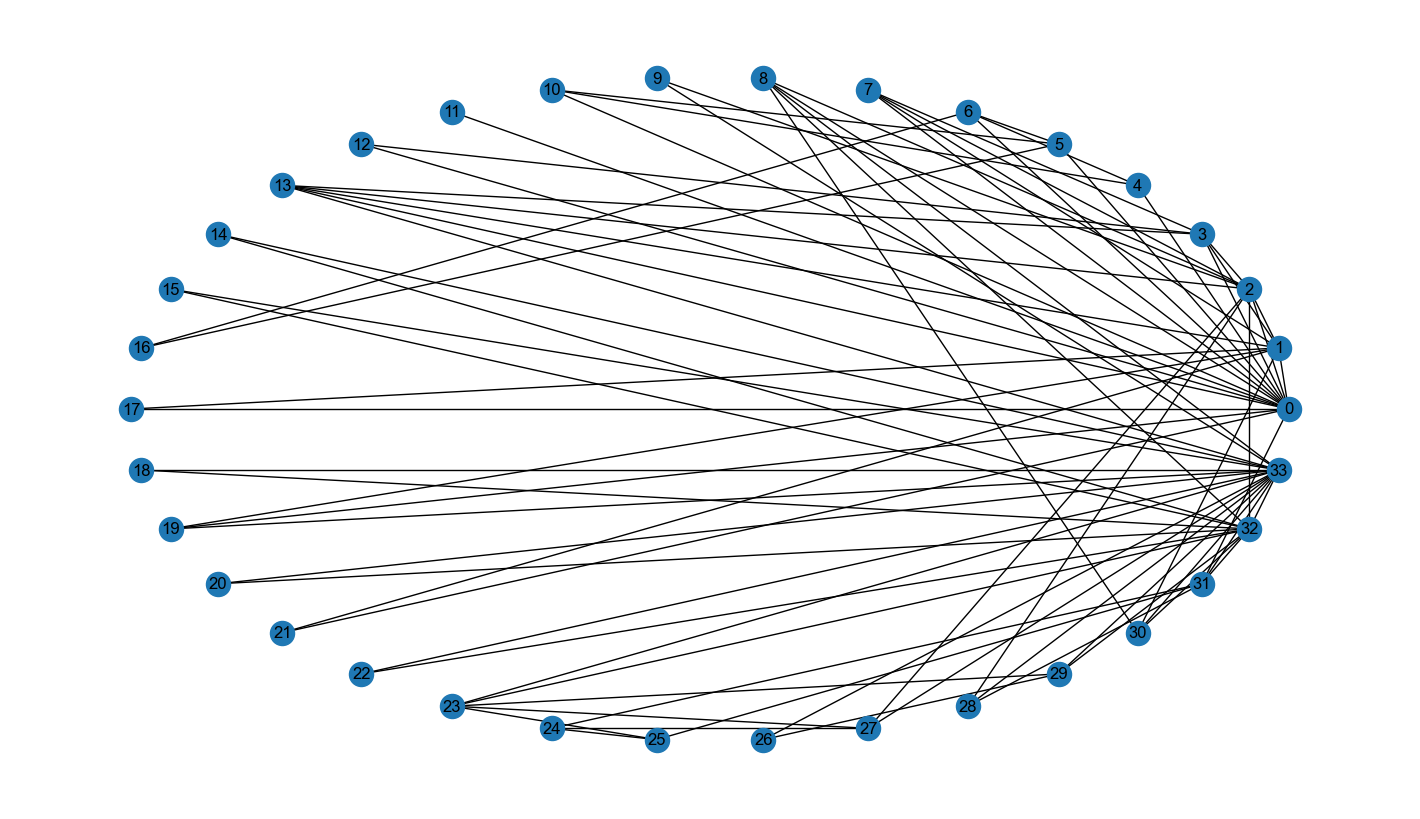

In [37]:
G = nx.karate_club_graph()
print("Node Degree")
for v in G:
    print(f"{v:4} {G.degree(v):6}")

nx.draw_circular(G, with_labels=True)
plt.show()

In [38]:
print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Graph type: {type(G)}")
print(f"Is directed: {G.is_directed()}")
# Convert directed graph to undirected
G_undirected = G.to_undirected()

# Remove any remaining self-loops
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

# Create unweighted adjacency matrix
A = nx.adjacency_matrix(G_undirected, weight=None).toarray()
N = G_undirected.number_of_nodes()
M = G_undirected.number_of_edges()  # Total number of edges

print(f"\nUndirected graph: {N} nodes, {M} edges")
print(f"Adjacency matrix shape: {A.shape}")
print(f"Sparsity: {(A == 0).sum() / A.size * 100:.2f}% zeros")
print(f"\nDegree statistics:")
degrees = [G_undirected.degree(n) for n in G_undirected.nodes()]
print(f"  Min: {min(degrees)}, Max: {max(degrees)}, Mean: {np.mean(degrees):.2f}")

Graph loaded: 34 nodes, 78 edges
Graph type: <class 'networkx.classes.graph.Graph'>
Is directed: False

Undirected graph: 34 nodes, 78 edges
Adjacency matrix shape: (34, 34)
Sparsity: 86.51% zeros

Degree statistics:
  Min: 1, Max: 17, Mean: 4.59


## Classical Community Detection (target # of communities: 4)

In [39]:
def communities_to_partition(communities):
    """
    Convert a list of community sets to a partition array.
    Returns: array where partition[i] = community_id for node i
    """
    node_list = list(G_undirected.nodes())  # Use the current graph's node order
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}
    partition = np.zeros(len(node_list), dtype=int)
    for community_id, community_set in enumerate(communities):
        for node in community_set:
            partition[node_to_idx[node]] = community_id
    return partition

def compute_modularity(partition, A):
    """
    Compute modularity Q for a given partition.
    Q = (1/2m) * sum_ij (A_ij - k_i*k_j/2m) * delta(c_i, c_j)
    where k_i is the degree of node i, and delta(c_i, c_j) = 1 if nodes i,j in same community
    """
    n = A.shape[0]

    degrees = A.sum(axis=1)
    m = A.sum() / 2.0  # total edges (double counted in adjacency matrix)
    
    Q = 0.0
    for i in range(n):
        for j in range(n):
            if partition[i] == partition[j]:
                Q += A[i, j] - (degrees[i] * degrees[j]) / (2.0 * m)
    
    Q /= (2.0 * m)
    return Q

def compute_conductance(partition, A):
    degrees = A.sum(axis=1)
    conductances = []
    for community_id in np.unique(partition):
        S  = np.where(partition == community_id)[0]
        if len(S) <= 1:
            continue
        Sc = np.where(partition != community_id)[0]
        if len(Sc) == 0:
            continue
        cut   = A[np.ix_(S, Sc)].sum()
        vol_S = degrees[S].sum()
        vol_c = degrees[Sc].sum()
        denom = min(vol_S, vol_c)
        if denom > 0:
            conductances.append(cut / denom)
    singleton_count = 0
    double_count = 0
    for community_id in np.unique(partition):
        S = np.where(partition == community_id)[0]
        if len(S) == 1:
            singleton_count += 1  # Max conductance for single-node communities
        if len(S) == 2:
            double_count += 1  # Max conductance for two-node communities
    return (np.mean(conductances)+(singleton_count/77)+(double_count/(77*2))) if conductances else np.nan


### 2.1 Louvain

In [40]:
start_time = time.time()
communities_louvain = list(nx.community.louvain_communities(G_undirected, seed=42))
louvain_runtime = time.time() - start_time

partition_louvain = communities_to_partition(communities_louvain)
modularity_louvain = compute_modularity(partition_louvain, A)
conductance_louvain = compute_conductance(partition_louvain, A)

print(f"Runtime: {louvain_runtime:.4f}s")
print(f"Number of communities: {len(communities_louvain)}")
print(f"Modularity: {modularity_louvain:.6f}")
print(f"Conductance: {conductance_louvain:.6f}")
print(f"Community sizes: {sorted([len(c) for c in communities_louvain], reverse=True)}")
print(f"Number of communities: {len(communities_louvain)}")

Runtime: 0.0144s
Number of communities: 4
Modularity: 0.390450
Conductance: 0.352778
Community sizes: [14, 10, 6, 4]
Number of communities: 4


### 2.2 Greedy modularity optimization

In [41]:
start_time = time.time()
communities_greedy = list(nx.community.greedy_modularity_communities(G_undirected))
greedy_runtime = time.time() - start_time

partition_greedy = communities_to_partition(communities_greedy)
modularity_greedy = compute_modularity(partition_greedy, A)
conductance_greedy = compute_conductance(partition_greedy, A)

print(f"Runtime: {greedy_runtime:.4f}s")
print(f"Number of communities: {len(communities_greedy)}")
print(f"Modularity: {modularity_greedy:.6f}")
print(f"Conductance: {conductance_greedy:.6f}")
print(f"Community sizes: {sorted([len(c) for c in communities_greedy], reverse=True)}")

Runtime: 0.0182s
Number of communities: 3
Modularity: 0.380671
Conductance: 0.280830
Community sizes: [17, 9, 8]


### 2.3 Greedy with best_n

In [42]:
start_time = time.time()
communities_greedy_bestn = list(nx.community.greedy_modularity_communities(G_undirected, best_n=math.sqrt(N)))
greedy_bestn_runtime = time.time() - start_time

partition_greedy_bestn = communities_to_partition(communities_greedy_bestn)
modularity_greedy_bestn = compute_modularity(partition_greedy_bestn, A)
conductance_greedy_bestn = compute_conductance(partition_greedy_bestn, A)

print(f"Runtime: {greedy_bestn_runtime:.4f}s")
print(f"Number of communities: {len(communities_greedy_bestn)}")
print(f"Modularity: {modularity_greedy_bestn:.6f}")
print(f"Conductance: {conductance_greedy_bestn:.6f}")
print(f"Community sizes: {sorted([len(c) for c in communities_greedy_bestn], reverse=True)}")

Runtime: 0.0184s
Number of communities: 3
Modularity: 0.380671
Conductance: 0.280830
Community sizes: [17, 9, 8]


# 3 QUBO with Modularity

### 3.1 Build QUBO Matrix

In [43]:
def build_modularity_qubo(A, num_communities=None, lambda_penalty=None, verbose=False):
    """
    Build QUBO matrix for modularity maximization via binary community assignment.
    Variables: x_{i,c} for i in nodes, c in communities
    Constraint: Each node assigned to exactly one community (handled via penalty)
    
    One-hot encoding:
    - num_binary_vars = N * num_communities
    - x[i*num_communities + c] = 1 if node i in community c
    
    QUBO objective: minimize -Q + lambda * penalty
    
    Parameters:
    -----------
    A : ndarray
        Adjacency matrix
    num_communities : int, optional
        Number of communities (default: sqrt(N))
    lambda_penalty : float, optional
        Penalty weight for one-hot constraint.
        If None, automatically set to 10x the max modularity contribution.
    verbose : bool
        Print diagnostics
    """

    if num_communities is None:
        num_communities = max(2, int(np.sqrt(N)))

    n_vars = N * num_communities 
    Q = {}

    degrees = A.sum(axis=1)
    m = A.sum() / 2  # Total edges

    # Modularity term: Q = (1/2m) * sum_{c} sum_{i,j} B_{ij} x_{i,c} x_{j,c}
    # For minimization, use -Q in QUBO objective
    max_B = 0  # Track max modularity contribution for scaling
    
    for c in range(num_communities):
        for i in range(N):
            for j in range(i, N):
                var_i = i * num_communities + c
                var_j = j * num_communities + c
                B_ij = A[i, j] - (degrees[i] * degrees[j]) / (2 * m)
                coeff = -B_ij / (2 * m)
                max_B = max(max_B, abs(coeff))

                if i == j:  # diagonal
                    if var_i not in Q:
                        Q[var_i] = 0.0
                    Q[var_i] += coeff
                else:  # off-diagonal
                    key = (var_i, var_j) if var_i < var_j else (var_j, var_i)
                    if key not in Q:
                        Q[key] = 0.0
                    Q[key] += coeff

    if lambda_penalty is None:
        lambda_penalty = max(10.0 * max_B, 5.0)  # At least 5.0
    
    if verbose:
        print(f"Modularity scale (max |coeff|): {max_B:.6f}")
        print(f"Penalty weight (lambda): {lambda_penalty:.6f}")

    # Constraint penalty: each node in exactly one community
    # Penalty: lambda * (sum_c x_{i,c} - 1)^2
    # Expansion:
    #   (sum_c x_{i,c} - 1)^2 = sum_c x_{i,c}^2 + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} - 2*sum_c x_{i,c} + 1
    #   = sum_c x_{i,c} + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} - 2*sum_c x_{i,c} + 1   [since x^2=x for binary]
    #   = -sum_c x_{i,c} + 2*sum_{c1<c2} x_{i,c1}*x_{i,c2} + 1
    
    # Linear coefficient: -lambda per variable
    # Quadratic coefficient: +2*lambda per pair

    const_term = N * lambda_penalty
    
    for i in range(N):
        # Linear terms: -lambda * x_{i,c}
        for c in range(num_communities):
            var_i = i * num_communities + c
            if var_i not in Q:
                Q[var_i] = 0.0
            Q[var_i] += -lambda_penalty

        # Quadratic terms: +2*lambda * x_{i,c1}*x_{i,c2}
        for c1 in range(num_communities):
            for c2 in range(c1 + 1, num_communities):
                var_1 = i * num_communities + c1
                var_2 = i * num_communities + c2
                key = (var_1, var_2) if var_1 < var_2 else (var_2, var_1)
                if key not in Q:
                    Q[key] = 0.0
                Q[key] += 2.0 * lambda_penalty

    Q['__const__'] = const_term
    
    if verbose:
        print(f"Constant term (N*lambda): {const_term:.2f}")
        print(f"Total QUBO terms: {len(Q)-1} + 1 const")  # -1 for const term itself

    return Q, num_communities

In [44]:
# Set number of estimated communities to 4 (can be tuned)
num_communities_target = 4
print(f"Target number of communities: {num_communities_target}")
print(f"Total QUBO variables: {N * num_communities_target}")

# Build QUBO
print(f"\nBuilding QUBO matrix...")
Q_dict, k_communities = build_modularity_qubo(A, num_communities_target, verbose=True)
print(f"QUBO built with {len(Q_dict)-1} terms")
print(f"Constant term: {Q_dict.get('__const__', 0):.2f}")

Target number of communities: 4
Total QUBO variables: 136

Building QUBO matrix...
Modularity scale (max |coeff|): 0.011875
Penalty weight (lambda): 5.000000
Constant term (N*lambda): 170.00
Total QUBO terms: 2584 + 1 const
QUBO built with 2584 terms
Constant term: 170.00


In [45]:
# Convert QUBO to BQM (Binary Quadratic Model) for D-Wave
Q_dict_clean = {}
const_offset = 0

for k, v in Q_dict.items():
    if k == '__const__':
        # Extract constant term for later addition
        const_offset = float(v)
    elif isinstance(k, tuple):
        Q_dict_clean[k] = float(v)
    else:
        node_idx = int(k)
        Q_dict_clean[(node_idx, node_idx)] = float(v)

# Create BQM and add the constant offset
bqm = dimod.BinaryQuadraticModel.from_qubo(Q_dict_clean)

# Add constant term to the BQM's offset
bqm.offset += const_offset

print(f"BQM created: {bqm.num_variables} variables, {len(bqm.quadratic)} interactions")
print(f"BQM offset (constant term): {bqm.offset:.2f}")

BQM created: 136 variables, 2448 interactions
BQM offset (constant term): 170.00


## 3.1 Classical Solvers

### Simulated annealing

In [46]:
start_time = time.time()
sa_sampler = SimulatedAnnealingSampler()
sampleset_sa = sa_sampler.sample(bqm, num_reads=100, seed=42)
sa_runtime = time.time() - start_time

best_sample_sa = sampleset_sa.first.sample
best_energy_sa = sampleset_sa.first.energy

print(f"Runtime: {sa_runtime:.4f}s")
print(f"Best energy: {best_energy_sa:.6f}")
print(f"Number of reads: 100")
print(f"Top 5 solutions:")

# Convert generator into list
top5 = list(sampleset_sa.data(['sample', 'energy', 'num_occurrences'], sorted_by='energy'))[:5]
for i, (sample, energy, num_occurrences) in enumerate(top5):
    print(f"  {i+1}. Energy: {energy:.6f}, Occurrences: {num_occurrences}")

Runtime: 0.5457s
Best energy: -0.016889
Number of reads: 100
Top 5 solutions:
  1. Energy: -0.016889, Occurrences: 1
  2. Energy: -0.011793, Occurrences: 1
  3. Energy: -0.011300, Occurrences: 1
  4. Energy: -0.011300, Occurrences: 1
  5. Energy: -0.003123, Occurrences: 1


In [47]:
def extract_communities_from_sample(sample, N, k_communities):
    """
    Extract community assignments from QUBO sample.
    For node i, find c where x_{i,c} = 1
    """
    partition = np.zeros(N, dtype=int)
    
    for i in range(N):
        # Find which community this node is assigned to
        for c in range(k_communities):
            var_idx = i * k_communities + c
            if var_idx in sample and sample[var_idx] == 1:
                partition[i] = c
                break
        else:
            # If no community assigned (constraint violation), assign to community 0
            partition[i] = 0
    
    return partition
count = 1

for sample, energy, num_occurrences in top5:
    partition_sa = extract_communities_from_sample(sample, N, k_communities)
    modularity_sa = compute_modularity(partition_sa, A)
    num_communities_found_sa = len(np.unique(partition_sa))
    
    print(f"\nPartition from sample with energy {energy:.6f}:")
    print(f"\nSample {count}:")
    print(f"  Number of communities found: {num_communities_found_sa}")
    print(f"  Modularity: {modularity_sa:.6f}")
    print(f"  Community sizes: {sorted(np.bincount(partition_sa), reverse=True)}")
    count += 1


Partition from sample with energy -0.016889:

Sample 1:
  Number of communities found: 4
  Modularity: 0.083580
  Community sizes: [np.int64(9), np.int64(9), np.int64(8), np.int64(8)]

Partition from sample with energy -0.011793:

Sample 2:
  Number of communities found: 4
  Modularity: 0.073389
  Community sizes: [np.int64(11), np.int64(10), np.int64(8), np.int64(5)]

Partition from sample with energy -0.011300:

Sample 3:
  Number of communities found: 4
  Modularity: 0.072403
  Community sizes: [np.int64(13), np.int64(8), np.int64(7), np.int64(6)]

Partition from sample with energy -0.011300:

Sample 4:
  Number of communities found: 4
  Modularity: 0.072403
  Community sizes: [np.int64(15), np.int64(9), np.int64(5), np.int64(5)]

Partition from sample with energy -0.003123:

Sample 5:
  Number of communities found: 4
  Modularity: 0.056049
  Community sizes: [np.int64(10), np.int64(10), np.int64(9), np.int64(5)]


## 3.2 Quantum/hybrid solvers

In [48]:
def greedy_refinement(A, partition):
    """
    Refines the partition using a greedy local search.
    Moves each node to the community that gives the highest modularity increase.
    """
    refined_partition = partition.copy()
    N = A.shape[0]
    unique_communities = np.unique(partition)
    improved = True
    
    current_modularity = compute_modularity(refined_partition, A)
    
    print(f"Starting refinement... Initial Modularity: {current_modularity:.6f}")
    
    while improved:
        improved = False
        nodes = np.random.permutation(N)
        
        for i in nodes:
            best_move = refined_partition[i]
            initial_comm = refined_partition[i]
            for target_comm in unique_communities:
                if target_comm == initial_comm:
                    continue
                refined_partition[i] = target_comm
                new_modularity = compute_modularity(refined_partition, A)
                if new_modularity > current_modularity:
                    current_modularity = new_modularity
                    best_move = target_comm
                    improved = True
            refined_partition[i] = best_move
            
    print(f"Refinement complete. Optimized Modularity: {current_modularity:.6f}")
    return refined_partition

def advanced_refinement(A, partition):
    N = A.shape[0]
    m = np.sum(A) / 2
    degrees = np.sum(A, axis=1)
    refined_partition = partition.copy()
    
    def get_delta_q(node_i, target_comm, curr_partition):
        # Calculate only the change in modularity for moving node_i
        # Internal edges to the target community
        comm_nodes = np.where(curr_partition == target_comm)[0]
        ki_in = np.sum(A[node_i, comm_nodes])
        ki = degrees[node_i]
        sum_tot = np.sum(degrees[comm_nodes])
        
        # Simplified Delta Q formula
        return (ki_in / m) - (sum_tot * ki) / (2 * m**2)

    improved = True
    while improved:
        improved = False
        nodes = np.random.permutation(N)
        for i in nodes:
            old_comm = refined_partition[i]
            # Only check communities that node i is actually connected to (saves time!)
            neighbor_nodes = np.where(A[i, :] > 0)[0]
            neighbor_comms = np.unique(refined_partition[neighbor_nodes])
            
            best_delta = 0
            best_move = old_comm
            
            for target_comm in neighbor_comms:
                if target_comm == old_comm: continue
                
                delta_q = get_delta_q(i, target_comm, refined_partition)
                if delta_q > best_delta:
                    best_delta = delta_q
                    best_move = target_comm
                    improved = True
            
            refined_partition[i] = best_move
            
    return refined_partition

### 3.2a D-Wave LeapHybrid (quantum + classical; requires Leap account)

In [49]:
start_time = time.time()
sampler = LeapHybridSampler()
sampleset_hybrid = sampler.sample(bqm, time_limit=10)

# target_edgelist = sampler.edgelist
# find_embedding(bqm.quadratic, target_edgelist)

# sampleset_hybrid = hybrid_sampler.sample(bqm, time_limit=1)
hybrid_runtime = time.time() - start_time

best_sample_hybrid = sampleset_hybrid.first.sample
best_energy_hybrid = sampleset_hybrid.first.energy
# use_hybrid = True

In [50]:
# Refine with greedy optimization
partition_hybrid_raw = extract_communities_from_sample(best_sample_hybrid, N, k_communities)
print("Applying greedy refinement to hybrid solution...")
partition_hybrid_optimized = greedy_refinement(A, partition_hybrid_raw)
partition_hybrid = extract_communities_from_sample(best_sample_hybrid, N, k_communities)

num_communities_found_hybrid = len(np.unique(partition_hybrid))
conductance_hybrid = compute_conductance(partition_hybrid, A)
mod_raw = compute_modularity(partition_hybrid_raw, A)
mod_opt = compute_modularity(partition_hybrid_optimized, A)

print(f"Runtime: {hybrid_runtime:.4f}s")
print(f"Best energy: {best_energy_hybrid:.6f}")
print(f"Number of communities found: {num_communities_found_hybrid}")
print(f"Original hybrid modularity: {mod_raw:.6f}")
print(f"Optimized hybrid modularity: {mod_opt:.6f}")
print(f"Conductance: {conductance_hybrid:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_hybrid), reverse=True)}")

Applying greedy refinement to hybrid solution...
Starting refinement... Initial Modularity: 0.170201
Refinement complete. Optimized Modularity: 0.392176
Runtime: 4.4908s
Best energy: -0.060199
Number of communities found: 4
Original hybrid modularity: 0.170201
Optimized hybrid modularity: 0.392176
Conductance: 0.653690
Community sizes: [np.int64(17), np.int64(9), np.int64(5), np.int64(3)]


### 3.2bi D-Wave QPU Sampler (Advantage 1)

In [51]:
Dsampler = DWaveSampler(solver={'name': 'Advantage_system4.1'})
print("Connected to sampler", Dsampler.solver.name)

qpu_sampler = EmbeddingComposite(Dsampler)
total_actual_qpu_micros = 0

# parameters
variables = list(bqm.variables)
chunk_size = 68
current_sample = {}
for i in range(N):
    # Randomly assign each node to ONE community (one-hot)
    comm = np.random.randint(0, k_communities)
    for c in range(k_communities):
        current_sample[i * k_communities + c] = 1 if c == comm else 0
total_qpu_time = 0

print(f"Starting QPU decomposition loop on: {Dsampler.properties['chip_id']}")

for i in range(0, len(variables), chunk_size):
    # Select a subset of variables to optimize
    subset = variables[i : i + chunk_size]

    fixed_vars = {v: current_sample[v] for v in variables if v not in subset}
    sub_bqm = bqm.copy()
    sub_bqm.fix_variables(fixed_vars)
    
    loop_start = time.time()
    
    try:
        sampleset = qpu_sampler.sample(sub_bqm, num_reads=1000, chain_strength=2.0, annealing_time=100, label=f'Part {i}')
        qpu_micros = sampleset.info['timing']['qpu_access_time']
        total_actual_qpu_micros += qpu_micros
        best_sub_sample = sampleset.first.sample
        current_sample.update(best_sub_sample)
        
    except ValueError as e:
        print(f"Sub-problem {i} failed: {e}")
        continue
        
    loop_end = time.time()
    
    elapsed = loop_end - loop_start
    total_qpu_time += elapsed
    
    print(f"Chunk {i//chunk_size + 1}: processed in {elapsed:.4f}s")

print(f"\nTotal Loop Runtime: {total_qpu_time:.4f}s")
total_qpu_seconds = total_actual_qpu_micros / 1000000
print(f"Total Pure QPU Access Time: {total_qpu_seconds:.6f}s")
print(f"Total QPU Seconds Per Read: {total_qpu_seconds / 1000:.6f}s")
best_sample_qpu = current_sample
partition_qpu = np.zeros(N, dtype=int)

Connected to sampler Advantage_system4.1
Starting QPU decomposition loop on: Advantage_system4.1
Chunk 1: processed in 44.2384s
Chunk 2: processed in 67.3504s

Total Loop Runtime: 111.5888s
Total Pure QPU Access Time: 0.462647s
Total QPU Seconds Per Read: 0.000463s


In [52]:
# Postprocessing
partition_qpu = np.zeros(N, dtype=int)
unassigned_nodes = 0

for i in range(N):
    node_vars = [current_sample.get(i * k_communities + c, 0) for c in range(k_communities)]
    
    if sum(node_vars) == 1:
        partition_qpu[i] = np.argmax(node_vars)
    elif sum(node_vars) > 1:
        partition_qpu[i] = np.argmax(node_vars)
    else:
        unassigned_nodes += 1
        partition_qpu[i] = 0 # This defaults to Community 0
print(f"Nodes failed by QPU: {unassigned_nodes} out of {N}")

print("Applying advanced refinement to QPU solution...")
partition_qpu_optimized = advanced_refinement(A, partition_qpu)

modularity_qpu = compute_modularity(partition_qpu_optimized, A)
conductance_qpu = compute_conductance(partition_qpu_optimized, A)
print(f"Advanced Optimized QPU Modularity: {modularity_qpu:.6f}")
print(f"Advanced Optimized QPU Conductance: {conductance_qpu:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_qpu_optimized), reverse=True)}")

Nodes failed by QPU: 0 out of 34
Applying advanced refinement to QPU solution...


Advanced Optimized QPU Modularity: 0.371795
Advanced Optimized QPU Conductance: 0.128205
Community sizes: [np.int64(17), np.int64(17)]


### 3.2bi D-Wave QPU Sampler (Advantage 2)

In [53]:
Dsampler = DWaveSampler(solver={'name': 'Advantage2_system1'})
print("Connected to sampler", Dsampler.solver.name)

qpu_sampler = EmbeddingComposite(Dsampler)
total_actual_qpu_micros = 0

# parameters
variables = list(bqm.variables)
chunk_size = 68
current_sample = {}
for i in range(N):
    # Randomly assign each node to ONE community (one-hot)
    comm = np.random.randint(0, k_communities)
    for c in range(k_communities):
        current_sample[i * k_communities + c] = 1 if c == comm else 0
total_qpu_time = 0

print(f"Starting QPU decomposition loop on: {Dsampler.properties['chip_id']}")

for i in range(0, len(variables), chunk_size):
    # Select a subset of variables to optimize
    subset = variables[i : i + chunk_size]

    fixed_vars = {v: current_sample[v] for v in variables if v not in subset}
    sub_bqm = bqm.copy()
    sub_bqm.fix_variables(fixed_vars)
    
    loop_start = time.time()
    
    try:
        sampleset = qpu_sampler.sample(sub_bqm, num_reads=1000, chain_strength=2.0, annealing_time=100, label=f'Part {i}')
        qpu_micros = sampleset.info['timing']['qpu_access_time']
        total_actual_qpu_micros += qpu_micros
        best_sub_sample = sampleset.first.sample
        current_sample.update(best_sub_sample)
        
    except ValueError as e:
        print(f"Sub-problem {i} failed: {e}")
        continue
        
    loop_end = time.time()
    
    elapsed = loop_end - loop_start
    total_qpu_time += elapsed
    
    print(f"Chunk {i//chunk_size + 1}: processed in {elapsed:.4f}s")

print(f"\nTotal Loop Runtime: {total_qpu_time:.4f}s")
total_qpu_seconds = total_actual_qpu_micros / 1000000
print(f"Total Pure QPU Access Time: {total_qpu_seconds:.6f}s")
print(f"Total QPU Seconds Per Read: {total_qpu_seconds / 1000:.6f}s")
best_sample_qpu = current_sample
partition_qpu = np.zeros(N, dtype=int)

Connected to sampler Advantage2_system1
Starting QPU decomposition loop on: Advantage2_system1
Chunk 1: processed in 58.0825s
Chunk 2: processed in 55.3931s

Total Loop Runtime: 113.4756s
Total Pure QPU Access Time: 0.530440s
Total QPU Seconds Per Read: 0.000530s


In [54]:
# Postprocessing
partition_qpu = np.zeros(N, dtype=int)
unassigned_nodes = 0
# Normalize all keys in current_sample to int (safety check)

for i in range(N):
    node_vars = [current_sample.get(i * k_communities + c, 0) for c in range(k_communities)]
    
    if sum(node_vars) == 1:
        partition_qpu[i] = np.argmax(node_vars)
    elif sum(node_vars) > 1:
        partition_qpu[i] = np.argmax(node_vars)
    else:
        unassigned_nodes += 1
        partition_qpu[i] = 0 # This defaults to Community 0
print(f"Nodes failed by QPU: {unassigned_nodes} out of {N}")

print("Applying advanced refinement to QPU solution...")
partition_qpu_optimized = advanced_refinement(A, partition_qpu)

modularity_qpu = compute_modularity(partition_qpu_optimized, A)
conductance_qpu = compute_conductance(partition_qpu_optimized, A)
print(f"Advanced Optimized QPU Modularity: {modularity_qpu:.6f}")
print(f"Advanced Optimized QPU Conductance: {conductance_qpu:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_qpu_optimized), reverse=True)}")

Nodes failed by QPU: 0 out of 34
Applying advanced refinement to QPU solution...
Advanced Optimized QPU Modularity: 0.371795
Advanced Optimized QPU Conductance: 0.128205
Community sizes: [np.int64(17), np.int64(17), np.int64(0), np.int64(0)]


# 4 Discrete Quadratic Model

In [55]:
def build_modularity_dqm(A, num_communities):
    """
    Build DQM (Discrete Quadratic Model) for modularity maximization.

    Variables: x_i for i in nodes, where x_i in {0, 1, ..., num_communities-1}
    x_i = c means node i is in community c

    Objective: minimize -Q, where Q is modularity
    """
    from dimod import DiscreteQuadraticModel
    
    dqm = DiscreteQuadraticModel()
    
    # Add variables: each node has discrete variable with num_communities possible values
    for i in range(N):
        dqm.add_variable(num_communities, label=i)
    
    degrees = A.sum(axis=1)
    m = A.sum() / 2
    
    # Modularity term: Q = (1/2m) * sum_{i<j} B_ij * delta(x_i, x_j)
    # Since DQM minimizes, we use -Q as objective
    for i in range(N):
        for j in range(i+1, N):
            B_ij = A[i, j] - (degrees[i] * degrees[j]) / (2 * m)
            coeff = -B_ij / (2 * m)  # Negative because we minimize -Q
            
            # For each community c, add quadratic term when both nodes are in c
            for c in range(num_communities):
                dqm.set_quadratic(i, j, {(c, c): coeff})
    
    return dqm
num_communities_dqm = 4
dqm = build_modularity_dqm(A, num_communities_dqm)
print(f"DQM built with {dqm.num_variables()} variables")

DQM built with 34 variables


In [56]:
start_time = time.time()
dqm_sampler = LeapHybridDQMSampler()
sampleset_dqm = dqm_sampler.sample_dqm(dqm, time_limit=10)
dqm_runtime = time.time() - start_time

best_sample_dqm = sampleset_dqm.first.sample
best_energy_dqm = sampleset_dqm.first.energy

print(f"DQM Runtime: {dqm_runtime:.4f}s")
print(f"Best energy: {best_energy_dqm:.6f}")


DQM Runtime: 2.6603s
Best energy: -0.234796


In [57]:
# Extract communities from DQM sample
partition_dqm = np.array([best_sample_dqm[i] for i in range(N)])
modularity_dqm = compute_modularity(partition_dqm, A)
conductance_dqm = compute_conductance(partition_dqm, A)
num_communities_found_dqm = len(np.unique(partition_dqm))

print(f"Number of communities found: {num_communities_found_dqm}")
print(f"DQM Modularity: {modularity_dqm:.6f}")
print(f"DQM Conductance: {conductance_dqm:.6f}")
print(f"Community sizes: {sorted(np.bincount(partition_dqm), reverse=True)}")


Number of communities found: 4
DQM Modularity: 0.419790
DQM Conductance: 0.287500
Community sizes: [np.int64(12), np.int64(11), np.int64(6), np.int64(5)]
